In [31]:
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt


In [6]:
DATA = Path("datasets")

In [7]:
df = pd.read_csv(DATA / 'bank_data.csv')

In [8]:
df

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,34,9,180,93023,1,8.9,3,0,1,0,0,0,0
1,2,38,14,130,95010,4,4.7,3,134,1,0,0,0,0
2,3,46,21,193,91604,2,8.1,3,0,1,0,0,0,0
3,4,38,13,119,94104,1,3.3,2,0,1,0,1,1,1
4,5,42,18,141,94114,3,5.0,3,0,1,1,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
475,476,38,13,129,92646,3,4.1,3,0,1,0,1,1,1
476,477,43,19,121,94720,1,0.7,2,0,1,0,1,1,1
477,478,28,4,112,90049,2,1.6,2,0,1,0,0,1,0
478,479,46,20,122,90065,3,3.0,3,0,1,0,1,1,1


In [9]:
df = df.drop(columns=["ID", "ZIP Code", "Experience", "CCAvg", "Personal Loan"])

In [10]:
df.columns

Index(['Age', 'Income', 'Family', 'Education', 'Mortgage',
       'Securities Account', 'CD Account', 'Online', 'CreditCard'],
      dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Age                 480 non-null    int64
 1   Income              480 non-null    int64
 2   Family              480 non-null    int64
 3   Education           480 non-null    int64
 4   Mortgage            480 non-null    int64
 5   Securities Account  480 non-null    int64
 6   CD Account          480 non-null    int64
 7   Online              480 non-null    int64
 8   CreditCard          480 non-null    int64
dtypes: int64(9)
memory usage: 33.9 KB


In [12]:
df.describe()

,Age,Income,Family,Education,Mortgage,Securities Account,CD Account,Online,CreditCard
count,480.000000,480.000000,480.000000,480.000000,480.000000,480.000000,480.000000,480.00000,480.000000
mean,45.066667,144.745833,2.612500,2.233333,100.845833,0.125000,0.291667,0.60625,0.297917
std,11.590964,31.584429,1.115393,0.753373,160.847862,0.331064,0.455004,0.48909,0.457820
min,26.000000,60.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000
25%,35.000000,122.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.00000,0.000000
50%,45.000000,142.500000,3.000000,2.000000,0.000000,0.000000,0.000000,1.00000,0.000000
75%,55.000000,172.000000,4.000000,3.000000,192.500000,0.000000,1.000000,1.00000,1.000000
max,65.000000,203.000000,4.000000,3.000000,617.000000,1.000000,1.000000,1.00000,1.000000


In [13]:

df.nunique()

Age                    40
Income                102
Family                  4
Education               3
Mortgage              141
Securities Account      2
CD Account              2
Online                  2
CreditCard              2
dtype: int64

In [14]:
df.to_csv(DATA / "bank_data_processed_2.csv")


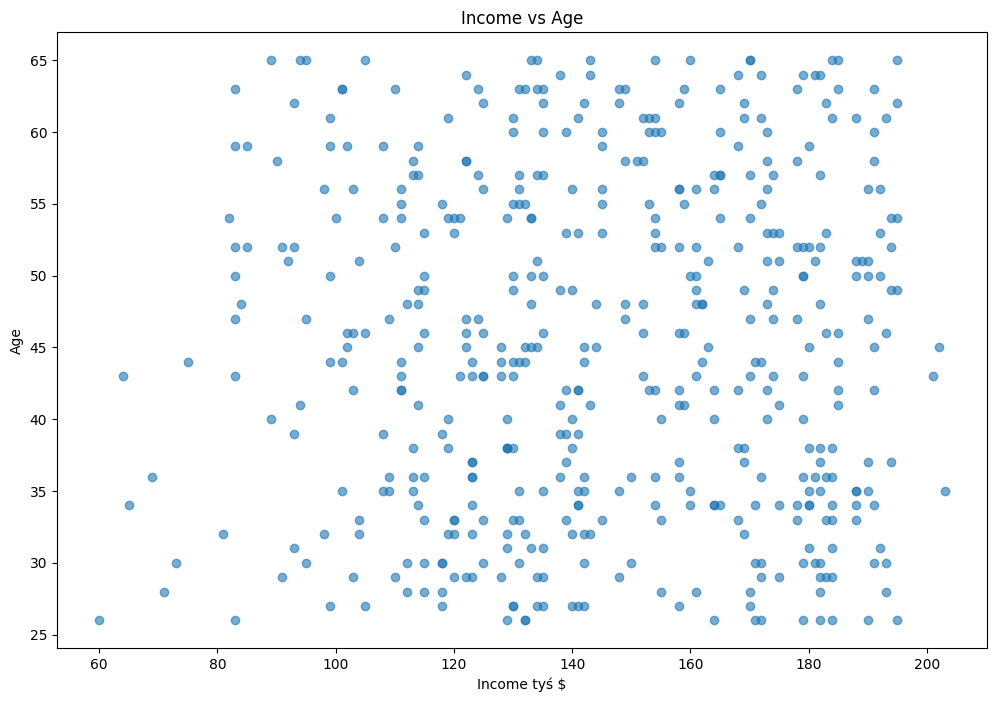

In [ ]:
fig, ax = plt.subplots(figsize=(12,8))

ax.scatter(df["Income"], df["Age"], alpha=0.6)

ax.set_title("Income vs Age")
ax.set_xlabel("Income tyś $")
ax.set_ylabel("Age")

plt.tight_layout()
plt.show()

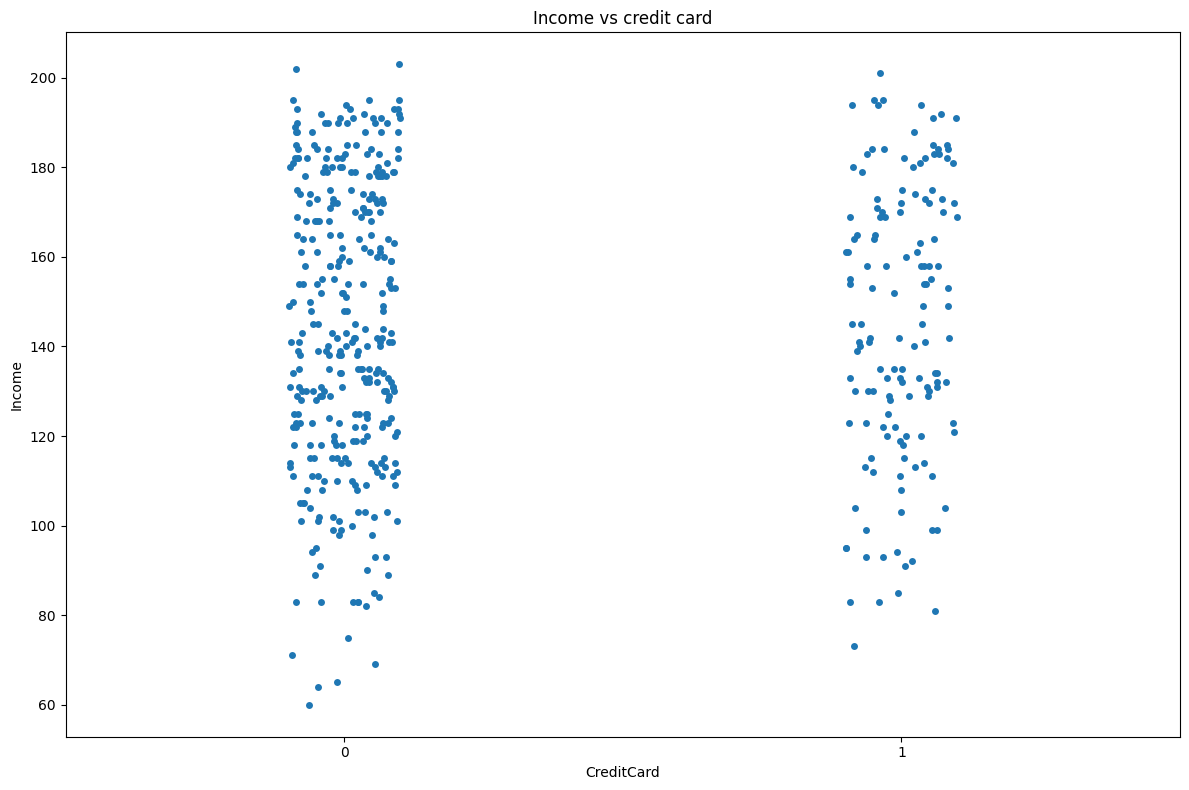

In [20]:
fig, ax = plt.subplots(figsize=(12,8))

sns.stripplot(
    x="CreditCard",
    y="Income",
    data=df,
    ax=ax
)

ax.set_title("Income vs credit card")


plt.tight_layout()
plt.show()

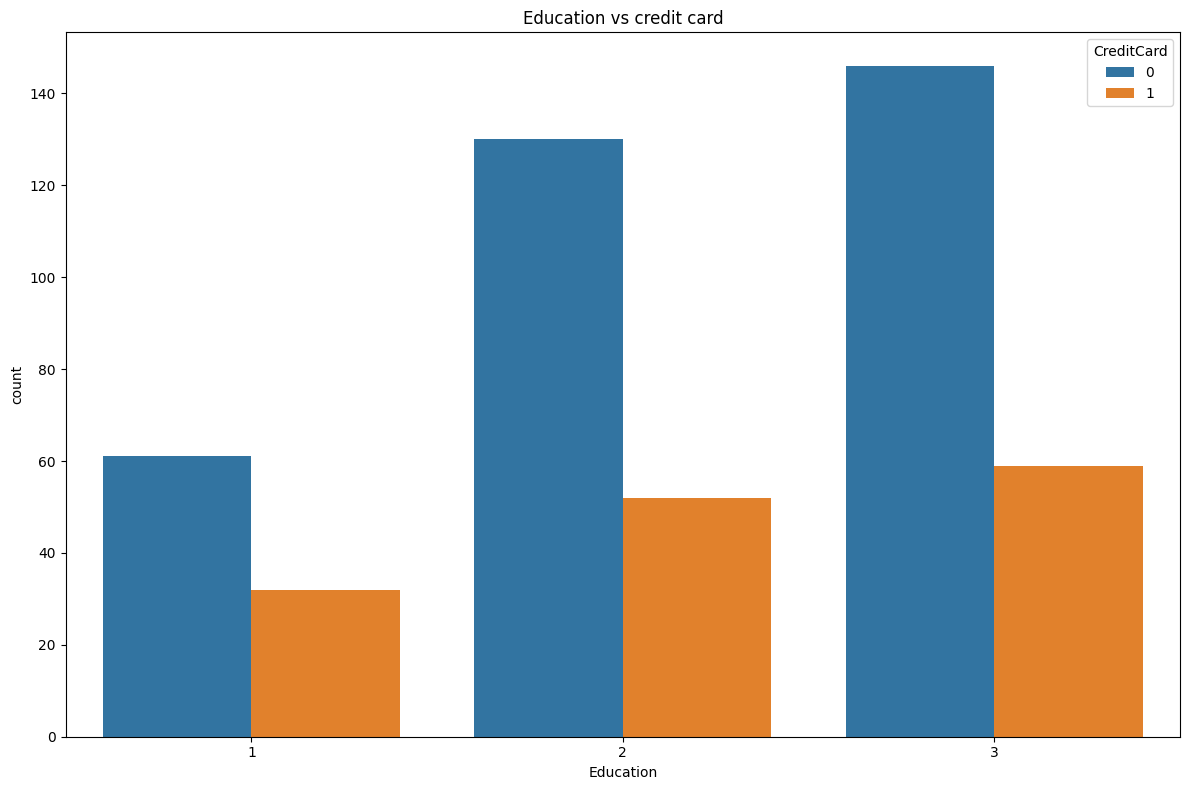

In [26]:
fig, ax = plt.subplots(figsize=(12,8))

sns.countplot(
    x="Education",
    
    data=df,
    ax=ax,
    hue="CreditCard"
)

ax.set_title("Education vs credit card")


plt.tight_layout()
plt.show()

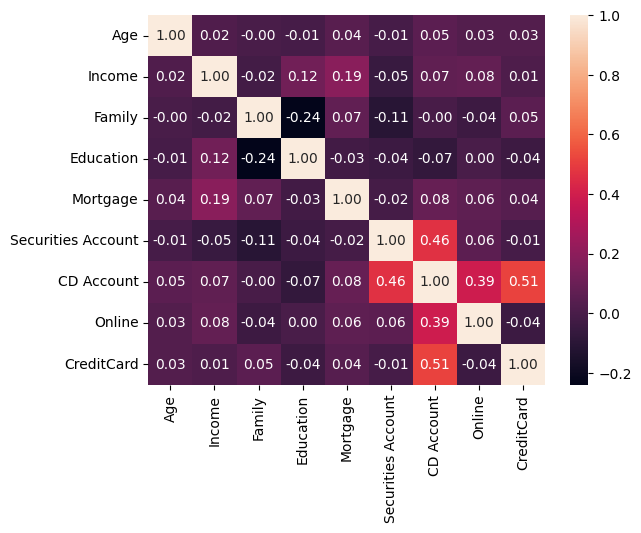

In [28]:
fig, ax = plt.subplots()

sns.heatmap(df.corr(), annot=True, ax=ax, fmt=".2f")

plt.show()

In [29]:
X = df.drop(columns="CreditCard")
y = df["CreditCard"]

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [35]:
log_clf = LogisticRegression(solver="liblinear")
svc_clf = SVC()
naive_clf = GaussianNB()

In [36]:
for clf in (log_clf, svc_clf, naive_clf):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    print(clf.__class__.__name__, accuracy_score(y_test, y_pred))

LogisticRegression 0.875
SVC 0.7291666666666666
GaussianNB 0.8229166666666666


In [37]:
voting_clf_hard = VotingClassifier(
    estimators=[
        ('lr', log_clf),
        ('svc', svc_clf),
        ('naive', naive_clf)
    ],
    voting='hard'
)

In [40]:
voting_clf_hard.fit(X_train, y_train)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('lr', ...), ('svc', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'hard'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001


In [41]:
y_pred = voting_clf_hard.predict(X_test)

In [42]:
accuracy_score(y_test, y_pred)

0.875

In [43]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.96      0.92        70
           1       0.85      0.65      0.74        26

    accuracy                           0.88        96
   macro avg       0.87      0.81      0.83        96
weighted avg       0.87      0.88      0.87        96



In [46]:
for clf in (log_clf, svc_clf, naive_clf, voting_clf_hard):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    print(clf.__class__.__name__, accuracy_score(y_test, y_pred))

LogisticRegression 0.875
SVC 0.7291666666666666
GaussianNB 0.8229166666666666
VotingClassifier 0.875


In [51]:
y_pred_probs = log_clf.predict_proba(X_test)

In [50]:
y_pred_probs

array([[0.6840549 , 0.3159451 ],
       [0.94925056, 0.05074944],
       [0.71972716, 0.28027284],
       [0.95048536, 0.04951464],
       [0.72064399, 0.27935601],
       [0.7090722 , 0.2909278 ],
       [0.94418683, 0.05581317],
       [0.94906851, 0.05093149],
       [0.69689778, 0.30310222],
       [0.20753787, 0.79246213],
       [0.69701769, 0.30298231],
       [0.23551561, 0.76448439],
       [0.95223423, 0.04776577],
       [0.68959729, 0.31040271],
       [0.2203857 , 0.7796143 ],
       [0.94292395, 0.05707605],
       [0.70240768, 0.29759232],
       [0.94645756, 0.05354244],
       [0.23225262, 0.76774738],
       [0.70803048, 0.29196952],
       [0.68260764, 0.31739236],
       [0.68253472, 0.31746528],
       [0.95060603, 0.04939397],
       [0.94911193, 0.05088807],
       [0.95316559, 0.04683441],
       [0.94907906, 0.05092094],
       [0.23978921, 0.76021079],
       [0.03882428, 0.96117572],
       [0.94224486, 0.05775514],
       [0.95021632, 0.04978368],
       [0.

In [57]:
svc_clf_soft = SVC(probability=True)

In [58]:
voting_clf_soft = VotingClassifier(
    estimators=[
        ('lr', log_clf),
        ('svc', svc_clf_soft),
        ('naive', naive_clf)
    ],
    voting='soft',
    weights=[0.4, 0.3, 0.3]
)

In [59]:
for clf in (log_clf, svc_clf, naive_clf, voting_clf_hard, voting_clf_soft):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    print(clf.__class__.__name__, accuracy_score(y_test, y_pred))

LogisticRegression 0.875
SVC 0.7291666666666666
GaussianNB 0.8229166666666666
VotingClassifier 0.875
VotingClassifier 0.875
